# Single models

## Setup

In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [3]:
import xarray as xr
import rioxarray as rxr

In [4]:
import rasterio

In [5]:
from imblearn.over_sampling import RandomOverSampler

In [6]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

In [7]:
from sklearn import metrics

In [8]:
from sklearn.inspection import PartialDependenceDisplay

In [9]:
import xgboost as xgb

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
import matplotlib.pyplot as plt

In [12]:
import matplotlib.cm as cm
import matplotlib.colors as colors

In [13]:
import sys
sys.path.insert(0, os.path.abspath('../scripts'))

In [14]:
from data_utils import xarray_pred_all_to_tif

In [15]:
DATA_DIR = '../data'

In [16]:
FIGURES_DIR = '../saved_figures'

## Load sampled data

In [17]:
samples_df = pd.read_csv(os.path.join(DATA_DIR, 'samples_v5.csv'))

In [18]:
samples_df = samples_df.drop(columns=['Unnamed: 0'])

In [19]:
samples_df.head()

,points,latitude,longitude,bitmask,Rnir,Rgli,logchl,logfb,Rw443,Rw490,...,Substrate,PercGravel,PercMud,PercSand,Presence,y,x,spatial_ref,tileId,tile_grid
0,13.0,55.222114,-6.630028,0.0,0.030331,0.001693,-0.094078,0.472445,0.021205,0.022442,...,4.0,16.742907,10.777808,72.61467,1.0,6122070.0,650750.0,0.0,29UPB,29UPB20
1,10.0,55.222555,-6.624970,0.0,0.030231,0.001702,0.072536,0.506929,0.018965,0.021337,...,4.0,15.857829,11.206201,73.08904,1.0,6122130.0,651070.0,0.0,29UPB,29UPB20
2,11.0,55.222510,-6.631891,0.0,0.031733,0.001689,0.220050,0.449105,0.013924,0.017181,...,4.0,17.361425,10.430368,72.32388,1.0,6122110.0,650630.0,0.0,29UPB,29UPB20
3,13.0,55.222114,-6.630028,0.0,0.030331,0.001693,-0.094078,0.472445,0.021205,0.022442,...,4.0,16.742907,10.777808,72.61467,1.0,6122070.0,650750.0,0.0,29UPB,29UPB20
4,9.0,55.222561,-6.625284,0.0,0.029630,0.001701,0.002956,0.515390,0.020957,0.022635,...,4.0,15.817097,11.216836,73.14491,1.0,6122130.0,651050.0,0.0,29UPB,29UPB20


In [20]:
samples_df = samples_df.dropna()

In [21]:
samples_df['Presence'].value_counts()

Presence
0.0    7951
1.0    2670
Name: count, dtype: int64

Rebalance dataset

In [22]:
absences = samples_df[samples_df['Presence'] == 0.0]

In [23]:
absences['tile_grid'].value_counts()

tile_grid
31UCS42    10
29UPB0     10
29UPB4     10
29UPB5     10
29UPB7     10
           ..
29VPE50     1
29VPE49     1
30VVL26     1
29VPC18     1
30VWL10     1
Name: count, Length: 1001, dtype: int64

In [24]:
max_removable = (
    absences.groupby('tile_grid')
       .size()
       .loc[lambda x: x == 10]
       .sum()
)

print(max_removable)

6080


In [25]:
# Split positives and negatives
pos = samples_df[samples_df['Presence'] == 1.0]
neg = samples_df[samples_df['Presence'] == 0.0]

target_negatives = len(pos)  # 2670
n_remove = len(neg) - target_negatives

print(f"Need to remove {n_remove} negatives")

# Count negatives per tile_grid
neg_counts = neg.groupby('tile_grid').size()

# Only tile_grids with exactly 10 negatives are eligible
eligible_tiles = neg_counts[neg_counts == 10].index

eligible_neg = neg[neg['tile_grid'].isin(eligible_tiles)]

# Number of eligible tile grids
n_tiles = len(eligible_tiles)

# Base number to remove from each eligible tile
base_remove = n_remove // n_tiles
remainder = n_remove % n_tiles

print(f"Removing {base_remove} per tile, plus 1 extra from {remainder} tiles")

# Randomly choose tiles that lose one extra sample
extra_tiles = set(
    np.random.choice(eligible_tiles, size=remainder, replace=False)
)

rows_to_drop = []

for tile in eligible_tiles:
    tile_rows = eligible_neg[eligible_neg['tile_grid'] == tile]

    n_drop = base_remove + (1 if tile in extra_tiles else 0)

    # Cannot remove more than exist
    n_drop = min(n_drop, len(tile_rows))

    rows_to_drop.extend(
        tile_rows.sample(n=n_drop, random_state=42).index
    )

# Create balanced dataframe
neg_balanced = neg.drop(rows_to_drop)

df_balanced = pd.concat([pos, neg_balanced], ignore_index=True)

print(df_balanced['Presence'].value_counts())

Need to remove 5281 negatives
Removing 8 per tile, plus 1 extra from 417 tiles
Presence
1.0    2670
0.0    2670
Name: count, dtype: int64


Correlation between Rw560 and bathymetry

## Load data tiles

In [27]:
def tileId_to_epsg(tileId):
    zone = int(tileId[:2])
    return f'EPSG:326{zone}'

In [28]:
data_tiles_all = {}
data_tiles_dir = os.path.join(DATA_DIR, 'data_tiles')
for f in os.listdir(data_tiles_dir):
    if not f.startswith('data_tile'):
        continue

    tile_id = f[10:15]

    f_full = os.path.join(data_tiles_dir, f)
    
    ds = xr.open_dataset(f_full, chunks={})

    if 'PercGravel' not in ds.data_vars:
        ds.close()
        continue
    
    data_tiles_all[tile_id] = ds
    data_tiles_all[tile_id].chunk({'y': 2048, 'x': 2048})
    tile_crs = tileId_to_epsg(tile_id)
    data_tiles_all[tile_id].rio.write_crs(tile_crs, inplace=True)

## Models

### Data setup

In [29]:
df_balanced.columns

Index(['points', 'latitude', 'longitude', 'bitmask', 'Rnir', 'Rgli', 'logchl',
       'logfb', 'Rw443', 'Rw490', 'Rw560', 'Rw665', 'Rw705', 'Rw740', 'Rw783',
       'Rw842', 'Rw865', 'Rw1610', 'bathymetry', 'SurveyKDE', 'ZM_Gauss',
       'grid_id', 'WavesKE', 'Substrate', 'PercGravel', 'PercMud', 'PercSand',
       'Presence', 'y', 'x', 'spatial_ref', 'tileId', 'tile_grid'],
      dtype='object')

In [30]:
df_balanced['NDTI'] = (df_balanced['Rw665'] - df_balanced['Rw560']) / (df_balanced['Rw665'] + df_balanced['Rw560'])

In [31]:
predictors = ['Rnir', 'Rw443', 'Rw490', 'Rw560', 'Rw665', 'logchl', 'bathymetry', 'WavesKE', 'PercGravel', 'PercMud', 'PercSand', 'NDTI']

In [32]:
groups = df_balanced['tile_grid']

In [33]:
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=100)

### Random Forest - repeats for error bars

In [44]:
feature_importances = np.zeros((5, len(predictors)), dtype='float')
fpr_list = []
tpr_list = []
roc_auc_list = []
metric_store = {'precision': [], 'recall': [], 'f1-score': []}
models = []

In [45]:
split_count = 0
for train_idx, test_idx in gss.split(df_balanced, groups=groups):
    train_data = df_balanced.iloc[train_idx]
    test_data = df_balanced.iloc[test_idx]
    
    X_train = train_data[predictors]
    X_test = test_data[predictors]
    y_train = train_data['Presence']
    y_test = test_data['Presence']

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=1,
        class_weight='balanced'
    )

    model.fit(X_train, y_train)
    models.append(model)

    # Feature importances
    feature_importances[split_count, :] = model.feature_importances_

    # ROC/AUC
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
    roc_auc = metrics.auc(fpr, tpr)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)

    # Store positive metrics
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores[np.isnan(f1_scores)] = 0.0
    best_threshold_index = np.argmax(f1_scores)

    metric_store['precision'].append(precision[best_threshold_index])
    metric_store['recall'].append(recall[best_threshold_index])
    metric_store['f1-score'].append(f1_scores[best_threshold_index])
    
    # y_pred = y_pred_proba.copy()
    # y_pred[y_pred_proba < 0.18] = 0.0
    # y_pred[y_pred_proba >= 0.18] = 1.0
    # report = classification_report(
    #     y_test,
    #     y_pred,
    #     output_dict=True,
    #     zero_division=0
    # )
    # for metric in ['precision', 'recall', 'f1-score']:
    #     metric_store[metric].append(report['1.0'][metric])

    # metric_store['accuracy'].append(report['accuracy'])
    
    split_count += 1

C:\Users\olley\AppData\Local\Temp\ipykernel_28936\779937639.py:36: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


In [46]:
feat_imp_mean = feature_importances.mean(axis=0)

In [47]:
feat_imp_mean

array([0.09219193, 0.0868473 , 0.08082249, 0.1155031 , 0.07113304,
       0.06592026, 0.15250549, 0.05192356, 0.07054379, 0.08783174,
       0.07192867, 0.05284863])

In [48]:
feat_imp_err = feature_importances.std(axis=0)

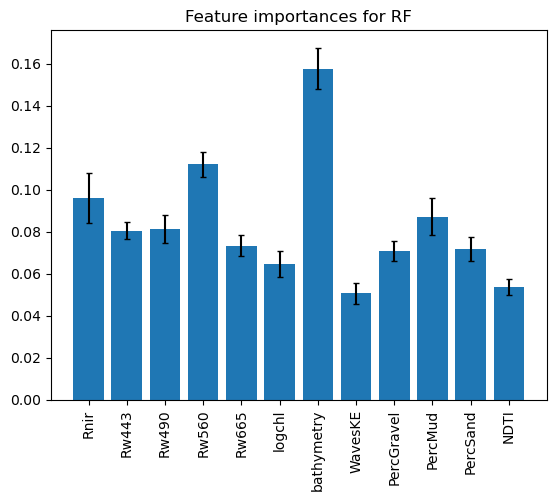

In [50]:
plt.bar(model.feature_names_in_, feat_imp_mean, yerr=feat_imp_err, capsize=2)
plt.xticks(rotation=90)
plt.title('Feature importances for RF')
plt.savefig(os.path.join(FIGURES_DIR, 'feat_imp_err'), dpi=300, bbox_inches='tight')

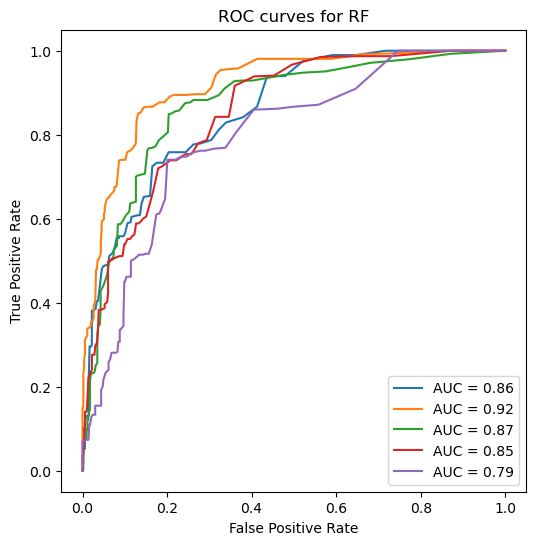

In [51]:
fig, ax = plt.subplots(figsize=(6, 6))
for i in range(len(fpr_list)):
    ax.plot(fpr_list[i], tpr_list[i], label=f'AUC = {roc_auc_list[i]:.2f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc=4)

plt.title('ROC curves for RF')
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curves_multi_rf'), dpi=300)

In [52]:
np.mean(roc_auc_list)

np.float64(0.8585676336102379)

In [53]:
(np.max(roc_auc_list) - np.min(roc_auc_list)) / 2

np.float64(0.06161192687054928)

In [54]:
np.mean(metric_store['f1-score'])

np.float64(0.8078792689629886)

In [55]:
(np.max(metric_store['f1-score']) - np.min(metric_store['f1-score'])) /2

np.float64(0.06440880307277069)

In [56]:
metric_means = {k: np.mean(v) for k, v in metric_store.items()}
metric_stds = {k: np.std(v) for k, v in metric_store.items()}

In [57]:
metric_means

{'precision': np.float64(0.7628404861520005),
 'recall': np.float64(0.867400158003705),
 'f1-score': np.float64(0.8078792689629886)}

In [58]:
metric_stds

{'precision': np.float64(0.07513921324533207),
 'recall': np.float64(0.0690172134298291),
 'f1-score': np.float64(0.048302275652370094)}

Text(0.5, 1.0, 'Classification metrics for RF')

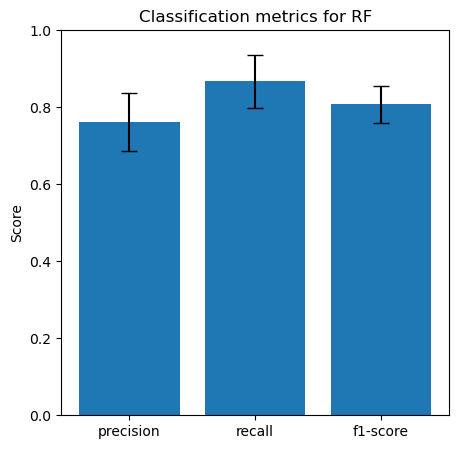

In [59]:
fig, ax = plt.subplots(figsize=(5,5))

metrics_to_plot = ["precision", "recall", "f1-score"]
means = [metric_means[m] for m in metrics_to_plot]
stds  = [metric_stds[m]  for m in metrics_to_plot]

ax.bar(
    metrics_to_plot,
    means,
    yerr=stds,
    capsize=6
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Classification metrics for RF")

# plt.savefig(os.path.join(FIGURES_DIR, 'metrics'), dpi=300)

In [51]:
X = df_balanced[predictors]
y = df_balanced['Presence']

In [52]:
i = 0
for train_idx, test_idx in gss.split(X, y, groups):
    if i == 1:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        break
    i += 1

In [53]:
y_pred_proba = models[1].predict_proba(X_test)[:,1]

In [54]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall)
nan_idx = np.isnan(f1_scores)
f1_scores[nan_idx] = 0.0
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")

Best Threshold: 0.25
Best F1-score: 0.87


In [55]:
precision[nan_idx] = np.nan
recall[nan_idx] = np.nan

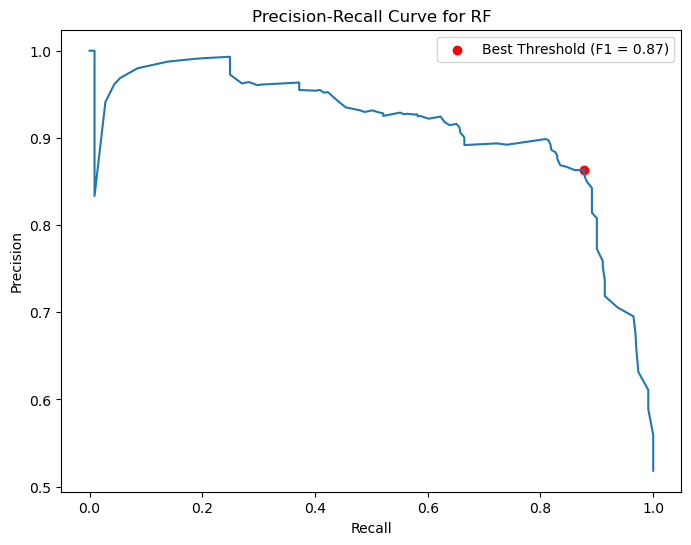

In [56]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.title('Precision-Recall Curve for RF')

ax.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.savefig(os.path.join(FIGURES_DIR, 'pr_curve_rf'), dpi=300)

**Partial dependence plots**

In [ ]:
bst_choice = models[1]

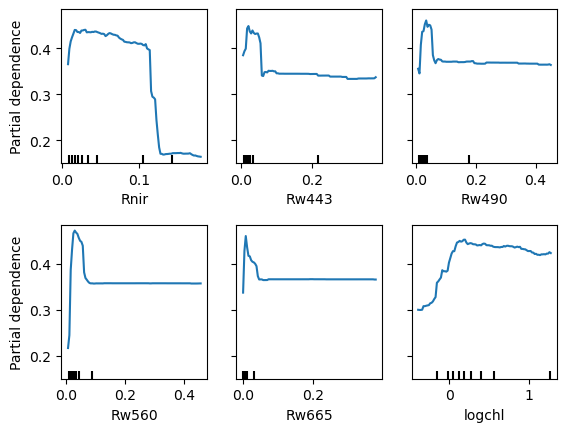

In [71]:
PartialDependenceDisplay.from_estimator(bst_choice, X_train, features=predictors[:6])
plt.subplots_adjust(hspace=0.4)
plt.savefig(os.path.join(FIGURES_DIR, 'part_dep1_rf'), dpi=300)

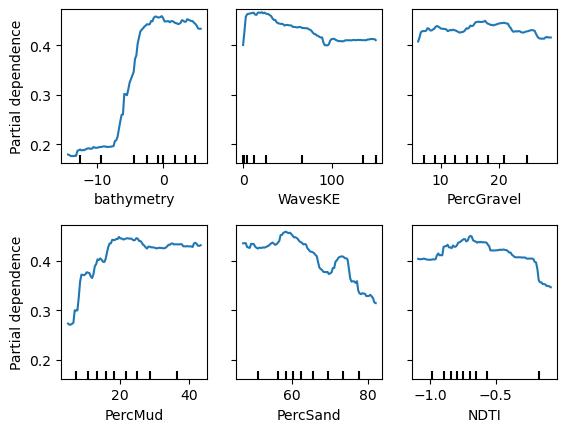

In [73]:
PartialDependenceDisplay.from_estimator(bst_choice, X_train, features=predictors[6:])
plt.subplots_adjust(hspace=0.4)
plt.savefig(os.path.join(FIGURES_DIR, 'part_dep2_rf'), dpi=300)

## XGBoost - repeats for hyper-parameter tuning

In [34]:
X = df_balanced[predictors]
y = df_balanced['Presence']

In [35]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 400]
}

In [36]:
inner_gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=101)

In [37]:
feature_importances_xgb = np.zeros((5, len(predictors)), dtype='float')
fpr_list_xgb = []
tpr_list_xgb = []
roc_auc_list_xgb = []
metric_store_xgb = {'precision': [], 'recall': [], 'f1-score': []}
xgb_models = []

split_count = 0
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups[train_idx]

    bst = xgb.XGBClassifier(
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    grid = GridSearchCV(
        estimator=bst,
        param_grid=param_grid,
        cv=inner_gss,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid.fit(X_train, y_train, groups=groups_train)

    best_model = grid.best_estimator_

    xgb_models.append(best_model)
    
    feature_importances_xgb[split_count, :] = best_model.feature_importances_

    y_pred_proba = best_model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
    roc_auc = metrics.auc(fpr, tpr)
    fpr_list_xgb.append(fpr)
    tpr_list_xgb.append(tpr)
    roc_auc_list_xgb.append(roc_auc)

    # Store positive metrics
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores[np.isnan(f1_scores)] = 0.0
    best_threshold_index = np.argmax(f1_scores)

    metric_store_xgb['precision'].append(precision[best_threshold_index])
    metric_store_xgb['recall'].append(recall[best_threshold_index])
    metric_store_xgb['f1-score'].append(f1_scores[best_threshold_index])
    
    split_count += 1

C:\Users\olley\AppData\Local\Temp\ipykernel_8196\38304830.py:47: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


In [38]:
feat_imp_mean_xgb = feature_importances_xgb.mean(axis=0)

In [81]:
feat_imp_mean_xgb

array([0.11384898, 0.09075052, 0.07794248, 0.14175418, 0.07113722,
       0.06530361, 0.1147487 , 0.05914506, 0.05883574, 0.09330989,
       0.06107214, 0.05215148])

In [82]:
feat_imp_err_xgb = feature_importances_xgb.std(axis=0)

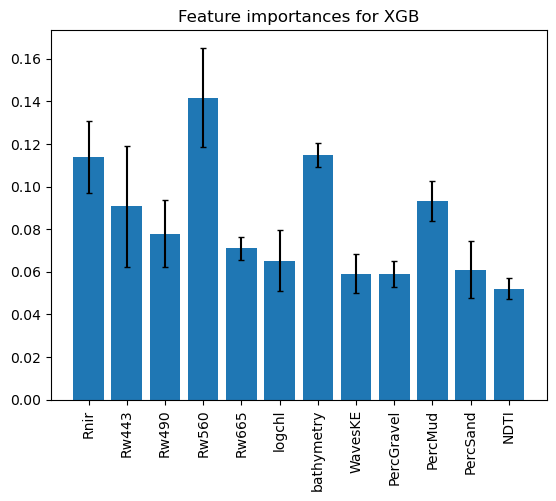

In [83]:
plt.bar(best_model.feature_names_in_, feat_imp_mean_xgb, yerr=feat_imp_err_xgb, capsize=2)
plt.xticks(rotation=90)
plt.title('Feature importances for XGB')
plt.savefig(os.path.join(FIGURES_DIR, 'feat_imp_err_xgb'), dpi=300, bbox_inches='tight')

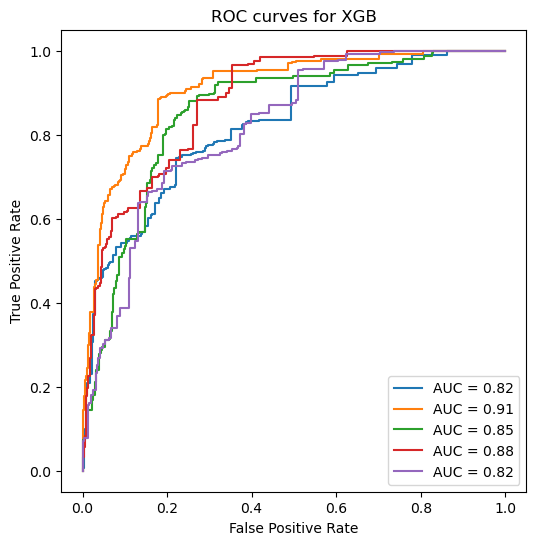

In [84]:
fig, ax = plt.subplots(figsize=(6, 6))
for i in range(len(fpr_list)):
    ax.plot(fpr_list_xgb[i], tpr_list_xgb[i], label=f'AUC = {roc_auc_list_xgb[i]:.2f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc=4)

plt.title('ROC curves for XGB')
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curves_multi_xgb'), dpi=300)

In [85]:
np.mean(roc_auc_list_xgb)

np.float64(0.8566286748974467)

In [86]:
(np.max(roc_auc_list_xgb) - np.min(roc_auc_list_xgb))/2

np.float64(0.04507041672936979)

In [87]:
np.mean(metric_store_xgb['f1-score'])

np.float64(0.8060529685721292)

In [88]:
(np.max(metric_store_xgb['f1-score']) - np.min(metric_store_xgb['f1-score'])) /2

np.float64(0.06974214634045756)

In [89]:
metric_means_xgb = {k: np.mean(v) for k, v in metric_store_xgb.items()}
metric_stds_xgb = {k: np.std(v) for k, v in metric_store_xgb.items()}

In [90]:
metric_means_xgb

{'precision': np.float64(0.7728792949363463),
 'recall': np.float64(0.8470609948785006),
 'f1-score': np.float64(0.8060529685721292)}

In [91]:
metric_stds_xgb

{'precision': np.float64(0.040135727298512336),
 'recall': np.float64(0.10013951324701226),
 'f1-score': np.float64(0.05913133494450831)}

Text(0.5, 1.0, 'Classification metrics for XGB')

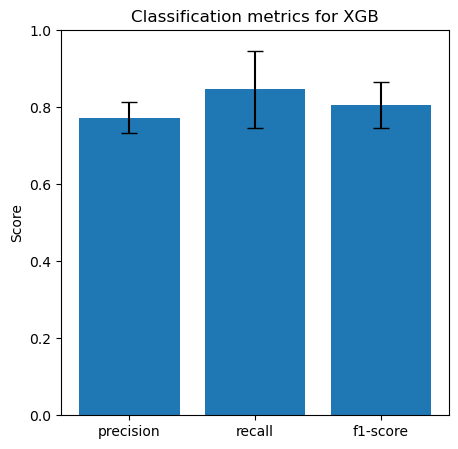

In [92]:
fig, ax = plt.subplots(figsize=(5,5))

metrics_to_plot = ["precision", "recall", "f1-score"]
means_xgb = [metric_means_xgb[m] for m in metrics_to_plot]
stds_xgb = [metric_stds_xgb[m]  for m in metrics_to_plot]

ax.bar(
    metrics_to_plot,
    means_xgb,
    yerr=stds_xgb,
    capsize=6
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Classification metrics for XGB")

# plt.savefig(os.path.join(FIGURES_DIR, 'metrics_xgb'), dpi=300)

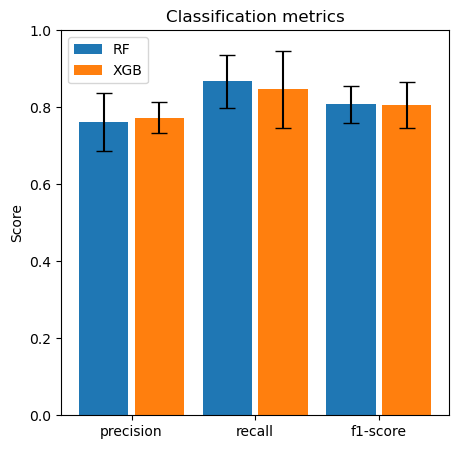

In [99]:
fig, ax = plt.subplots(figsize=(5,5))

metrics_to_plot = ["precision", "recall", "f1-score"]
means_xgb = [metric_means_xgb[m] for m in metrics_to_plot]
stds_xgb = [metric_stds_xgb[m]  for m in metrics_to_plot]

x_loc = np.arange(len(metrics_to_plot))
w = 0.4

ax.bar(
    x_loc - 9*w/16,
    means,
    yerr=stds,
    width=w,
    capsize=6,
    label='RF'
)

ax.bar(
    x_loc + 9*w/16,
    means_xgb,
    yerr=stds_xgb,
    width=w,
    capsize=6,
    label='XGB'
)

ax.set_xticks(x_loc)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Classification metrics")
ax.legend()

plt.savefig(os.path.join(FIGURES_DIR, 'metrics'), dpi=300)

In [39]:
bst_choice = xgb_models[1]

In [40]:
i = 0
for train_idx, test_idx in gss.split(X, y, groups):
    if i == 1:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        break
    i += 1

In [41]:
y_pred_proba = bst_choice.predict_proba(X_test)[:,1]

In [42]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall)
nan_idx = np.isnan(f1_scores)
f1_scores[nan_idx] = 0.0
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")

Best Threshold: 0.48
Best F1-score: 0.86


In [43]:
precision[nan_idx] = np.nan
recall[nan_idx] = np.nan

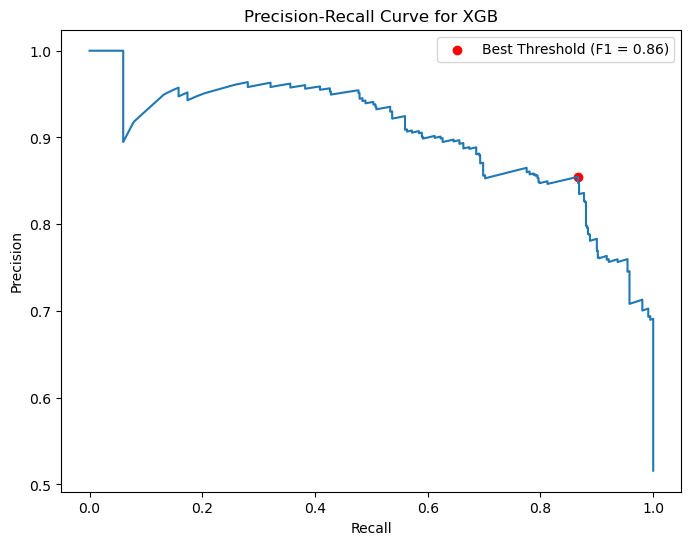

In [44]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.title('Precision-Recall Curve for XGB')

ax.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.savefig(os.path.join(FIGURES_DIR, 'pr_curve_xgb'), dpi=300)

**Partial dependence plots**

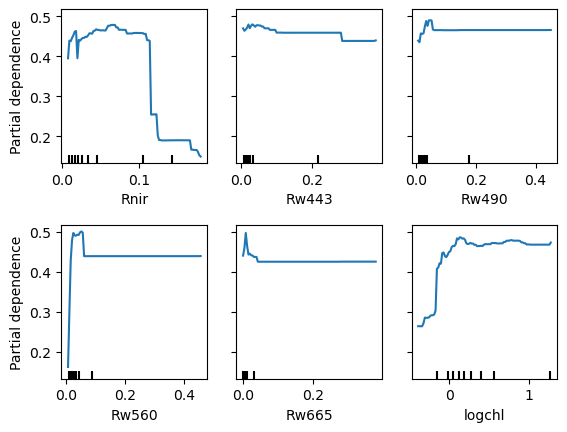

In [106]:
PartialDependenceDisplay.from_estimator(bst_choice, X_train, features=predictors[:6])
plt.subplots_adjust(hspace=0.4)
plt.savefig(os.path.join(FIGURES_DIR, 'part_dep1_xgb'), dpi=300)

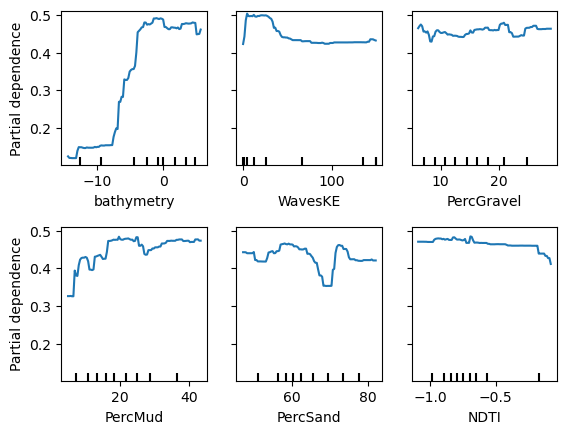

In [107]:
PartialDependenceDisplay.from_estimator(bst_choice, X_train, features=predictors[6:])
plt.subplots_adjust(hspace=0.4)
plt.savefig(os.path.join(FIGURES_DIR, 'part_dep2_xgb'), dpi=300)

## Prediction

### To TIFF

In [111]:
for tileId, ds in data_tiles_all.items():
    ds['bathymask'] = (ds['bathymetry'] > -15.0) & (ds['grid_id'] != 0.0) & (~np.isnan(ds['Rw490']))
    ds['NDTI'] = (ds['Rw665'] - ds['Rw560']) / (ds['Rw665'] + ds['Rw560'])

In [112]:
pred_dir = os.path.join(DATA_DIR, 'predictions/balanced')

In [114]:
rf_dir = os.path.join(pred_dir, 'rf')
tile_to_file = xarray_pred_all_to_tif(data_tiles_all, models[1], predictors, rf_dir, mask_band='bathymask')

Predicting for 29UPB...
Saved GeoTIFF: ../data\predictions/balanced\rf\29UPB_pred.tif
Prediction completed for 29UPB
Predicting for 29UPR...
Saved GeoTIFF: ../data\predictions/balanced\rf\29UPR_pred.tif
Prediction completed for 29UPR
Predicting for 29VPC...
Saved GeoTIFF: ../data\predictions/balanced\rf\29VPC_pred.tif
Prediction completed for 29VPC
Predicting for 29VPE...
Saved GeoTIFF: ../data\predictions/balanced\rf\29VPE_pred.tif
Prediction completed for 29VPE
Predicting for 30UUA...
Saved GeoTIFF: ../data\predictions/balanced\rf\30UUA_pred.tif
Prediction completed for 30UUA
Predicting for 30UUB...
Saved GeoTIFF: ../data\predictions/balanced\rf\30UUB_pred.tif
Prediction completed for 30UUB
Predicting for 30UUC...
Saved GeoTIFF: ../data\predictions/balanced\rf\30UUC_pred.tif
Prediction completed for 30UUC
Predicting for 30UUD...
Saved GeoTIFF: ../data\predictions/balanced\rf\30UUD_pred.tif
Prediction completed for 30UUD
Predicting for 30UUE...
Saved GeoTIFF: ../data\predictions/balan

In [115]:
xgb_dir = os.path.join(pred_dir, 'xgb')
tile_to_file = xarray_pred_all_to_tif(data_tiles_all, bst_choice, predictors, xgb_dir, mask_band='bathymask')

Predicting for 29UPB...
Saved GeoTIFF: ../data\predictions/balanced\xgb\29UPB_pred.tif
Prediction completed for 29UPB
Predicting for 29UPR...
Saved GeoTIFF: ../data\predictions/balanced\xgb\29UPR_pred.tif
Prediction completed for 29UPR
Predicting for 29VPC...
Saved GeoTIFF: ../data\predictions/balanced\xgb\29VPC_pred.tif
Prediction completed for 29VPC
Predicting for 29VPE...
Saved GeoTIFF: ../data\predictions/balanced\xgb\29VPE_pred.tif
Prediction completed for 29VPE
Predicting for 30UUA...
Saved GeoTIFF: ../data\predictions/balanced\xgb\30UUA_pred.tif
Prediction completed for 30UUA
Predicting for 30UUB...
Saved GeoTIFF: ../data\predictions/balanced\xgb\30UUB_pred.tif
Prediction completed for 30UUB
Predicting for 30UUC...
Saved GeoTIFF: ../data\predictions/balanced\xgb\30UUC_pred.tif
Prediction completed for 30UUC
Predicting for 30UUD...
Saved GeoTIFF: ../data\predictions/balanced\xgb\30UUD_pred.tif
Prediction completed for 30UUD
Predicting for 30UUE...
Saved GeoTIFF: ../data\predictio